**Homework 2**

*Instructions:* Please complete the following project and submit your solution by the next class session.

1. **Models and Regularization**
    - Recall the definitions of OLS, Ridge, and Lasso regression, and Logistic regression.
    -  How do they differ in terms of their assumptions, regularization techniques, and use cases? 
    - Provide a brief explanation for each.

2. **Dataset Analysis and Classification**

    - Load the dataset [`data/UCI_Credit_Card.csv`](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)
    
    - Rename the target variable `"default.payment.next.month"` to `"DEFAULT`"
    
    - Identify numerical vs categorical features and any variables requiring encoding or preprocessing.
    
    - Perform exploratory data analysis to understand the structure of the data. Comment on the data,identify any missing values, and visualize the relationships between features and the target variable. Briefly comment on any notable patterns or potential modeling challenges.

    - Train a LogisticRegression model to predict the default of credit card clients. Specify the train/test split strategy. Evaluate the model's performance using appropriate metrics (ROC, confusion matrix, etc). Briefly comment on any notable patterns or potential modeling challenges.
    
    - Model comparison: try at least two other classifiers from sklearn. Compare their performance with Logistic Regression. Use the same preprocessing, split, and evaluation metric for all models.

# Part 1 — Models and Regularization

## OLS (Ordinary Least Squares) Regression

**Definition:**  
Minimizes the sum of squared residuals:
$$\hat{\beta}^{\text{OLS}} = \arg\min_{\beta} \|y - X\beta\|_2^2 = (X^\top X)^{-1} X^\top y$$

**Assumptions:** Linear relationship, homoscedasticity, no multicollinearity, errors $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

**Regularization:** None.

**Use case:** When $p \ll n$, features are not highly correlated, and interpretability matters.

---

## Ridge Regression ($\ell_2$ regularization)

**Definition:**  
Adds a squared $\ell_2$ penalty on the coefficients:
$$\hat{\beta}^{\text{Ridge}} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \alpha \|\beta\|_2^2$$

Closed form: $\hat{\beta}^{\text{Ridge}} = (X^\top X + \alpha I)^{-1} X^\top y$

**Effect:** Shrinks all coefficients toward zero but never sets them exactly to zero. Stabilizes estimation under multicollinearity.

**Use case:** Many correlated features; all features are expected to contribute (dense solution).

---

## Lasso Regression ($\ell_1$ regularization)

**Definition:**  
Adds an $\ell_1$ penalty:
$$\hat{\beta}^{\text{Lasso}} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \alpha \|\beta\|_1$$

No closed form — solved via coordinate descent.

**Effect:** Shrinks coefficients and sets some **exactly to zero** → automatic feature selection (sparse solution).

**Use case:** High-dimensional problems where only a few features are truly relevant.

---

## Logistic Regression (Classification)

**Definition:**  
Models the probability of class 1 via the sigmoid function:
$$P(y=1 \mid x) = \sigma(\beta^\top x) = \frac{1}{1 + e^{-\beta^\top x}}$$

Parameters are estimated by maximizing the log-likelihood (equivalent to minimizing cross-entropy loss):
$$\hat{\beta} = \arg\min_{\beta} -\sum_{i} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]$$

**Assumptions:** Linear decision boundary in feature space; observations are independent.

**Regularization:** $\ell_1$ (`penalty='l1'`) or $\ell_2$ (`penalty='l2'`, default) can be added.

**Use case:** Binary classification where interpretability and probability estimates are needed.

# Part 2 — Dataset Analysis and Classification

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

## Load Data

In [3]:
df = pd.read_csv("data/UCI_Credit_Card.csv", index_col="ID")
df.rename(columns={"default.payment.next.month": "DEFAULT"}, inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AMT4   

In [5]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

Total missing: 0


In [7]:
# Feature types
# Categorical (encoded as integers): SEX, EDUCATION, MARRIAGE, PAY_0..PAY_6
# Continuous/numerical: LIMIT_BAL, AGE, BILL_AMT1..6, PAY_AMT1..6

cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
            "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
            "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

print("Categorical columns:", cat_cols)
print("\nValue counts for SEX:", df["SEX"].value_counts().to_dict())
print("Value counts for EDUCATION:", df["EDUCATION"].value_counts().to_dict())
print("Value counts for MARRIAGE:", df["MARRIAGE"].value_counts().to_dict())

Categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Value counts for SEX: {2: 18112, 1: 11888}
Value counts for EDUCATION: {2: 14030, 1: 10585, 3: 4917, 5: 280, 4: 123, 6: 51, 0: 14}
Value counts for MARRIAGE: {2: 15964, 1: 13659, 3: 323, 0: 54}


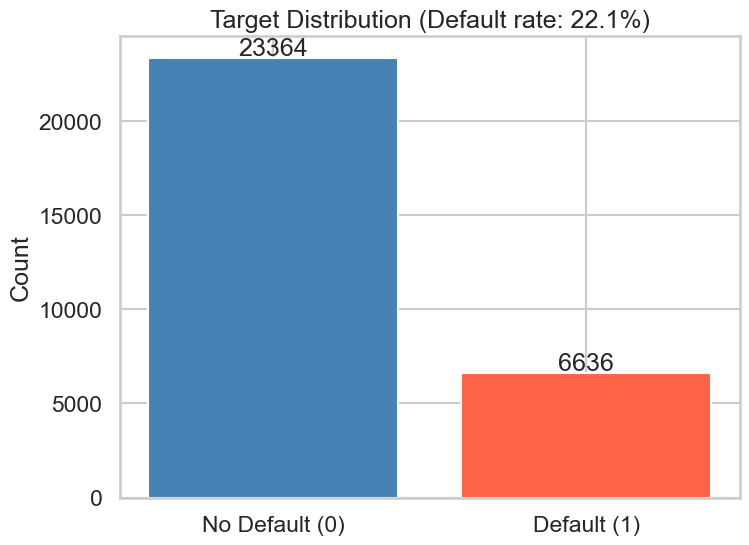

Class imbalance: 23364 non-defaults vs 6636 defaults (22.1% default rate)


In [8]:
# Target distribution
fig, ax = plt.subplots()
counts = df["DEFAULT"].value_counts()
ax.bar(["No Default (0)", "Default (1)"], counts.values, color=["steelblue", "tomato"])
ax.set_ylabel("Count")
ax.set_title(f"Target Distribution (Default rate: {counts[1]/len(df):.1%})")
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha="center")
plt.show()

print(f"Class imbalance: {counts[0]} non-defaults vs {counts[1]} defaults ({counts[1]/len(df):.1%} default rate)")

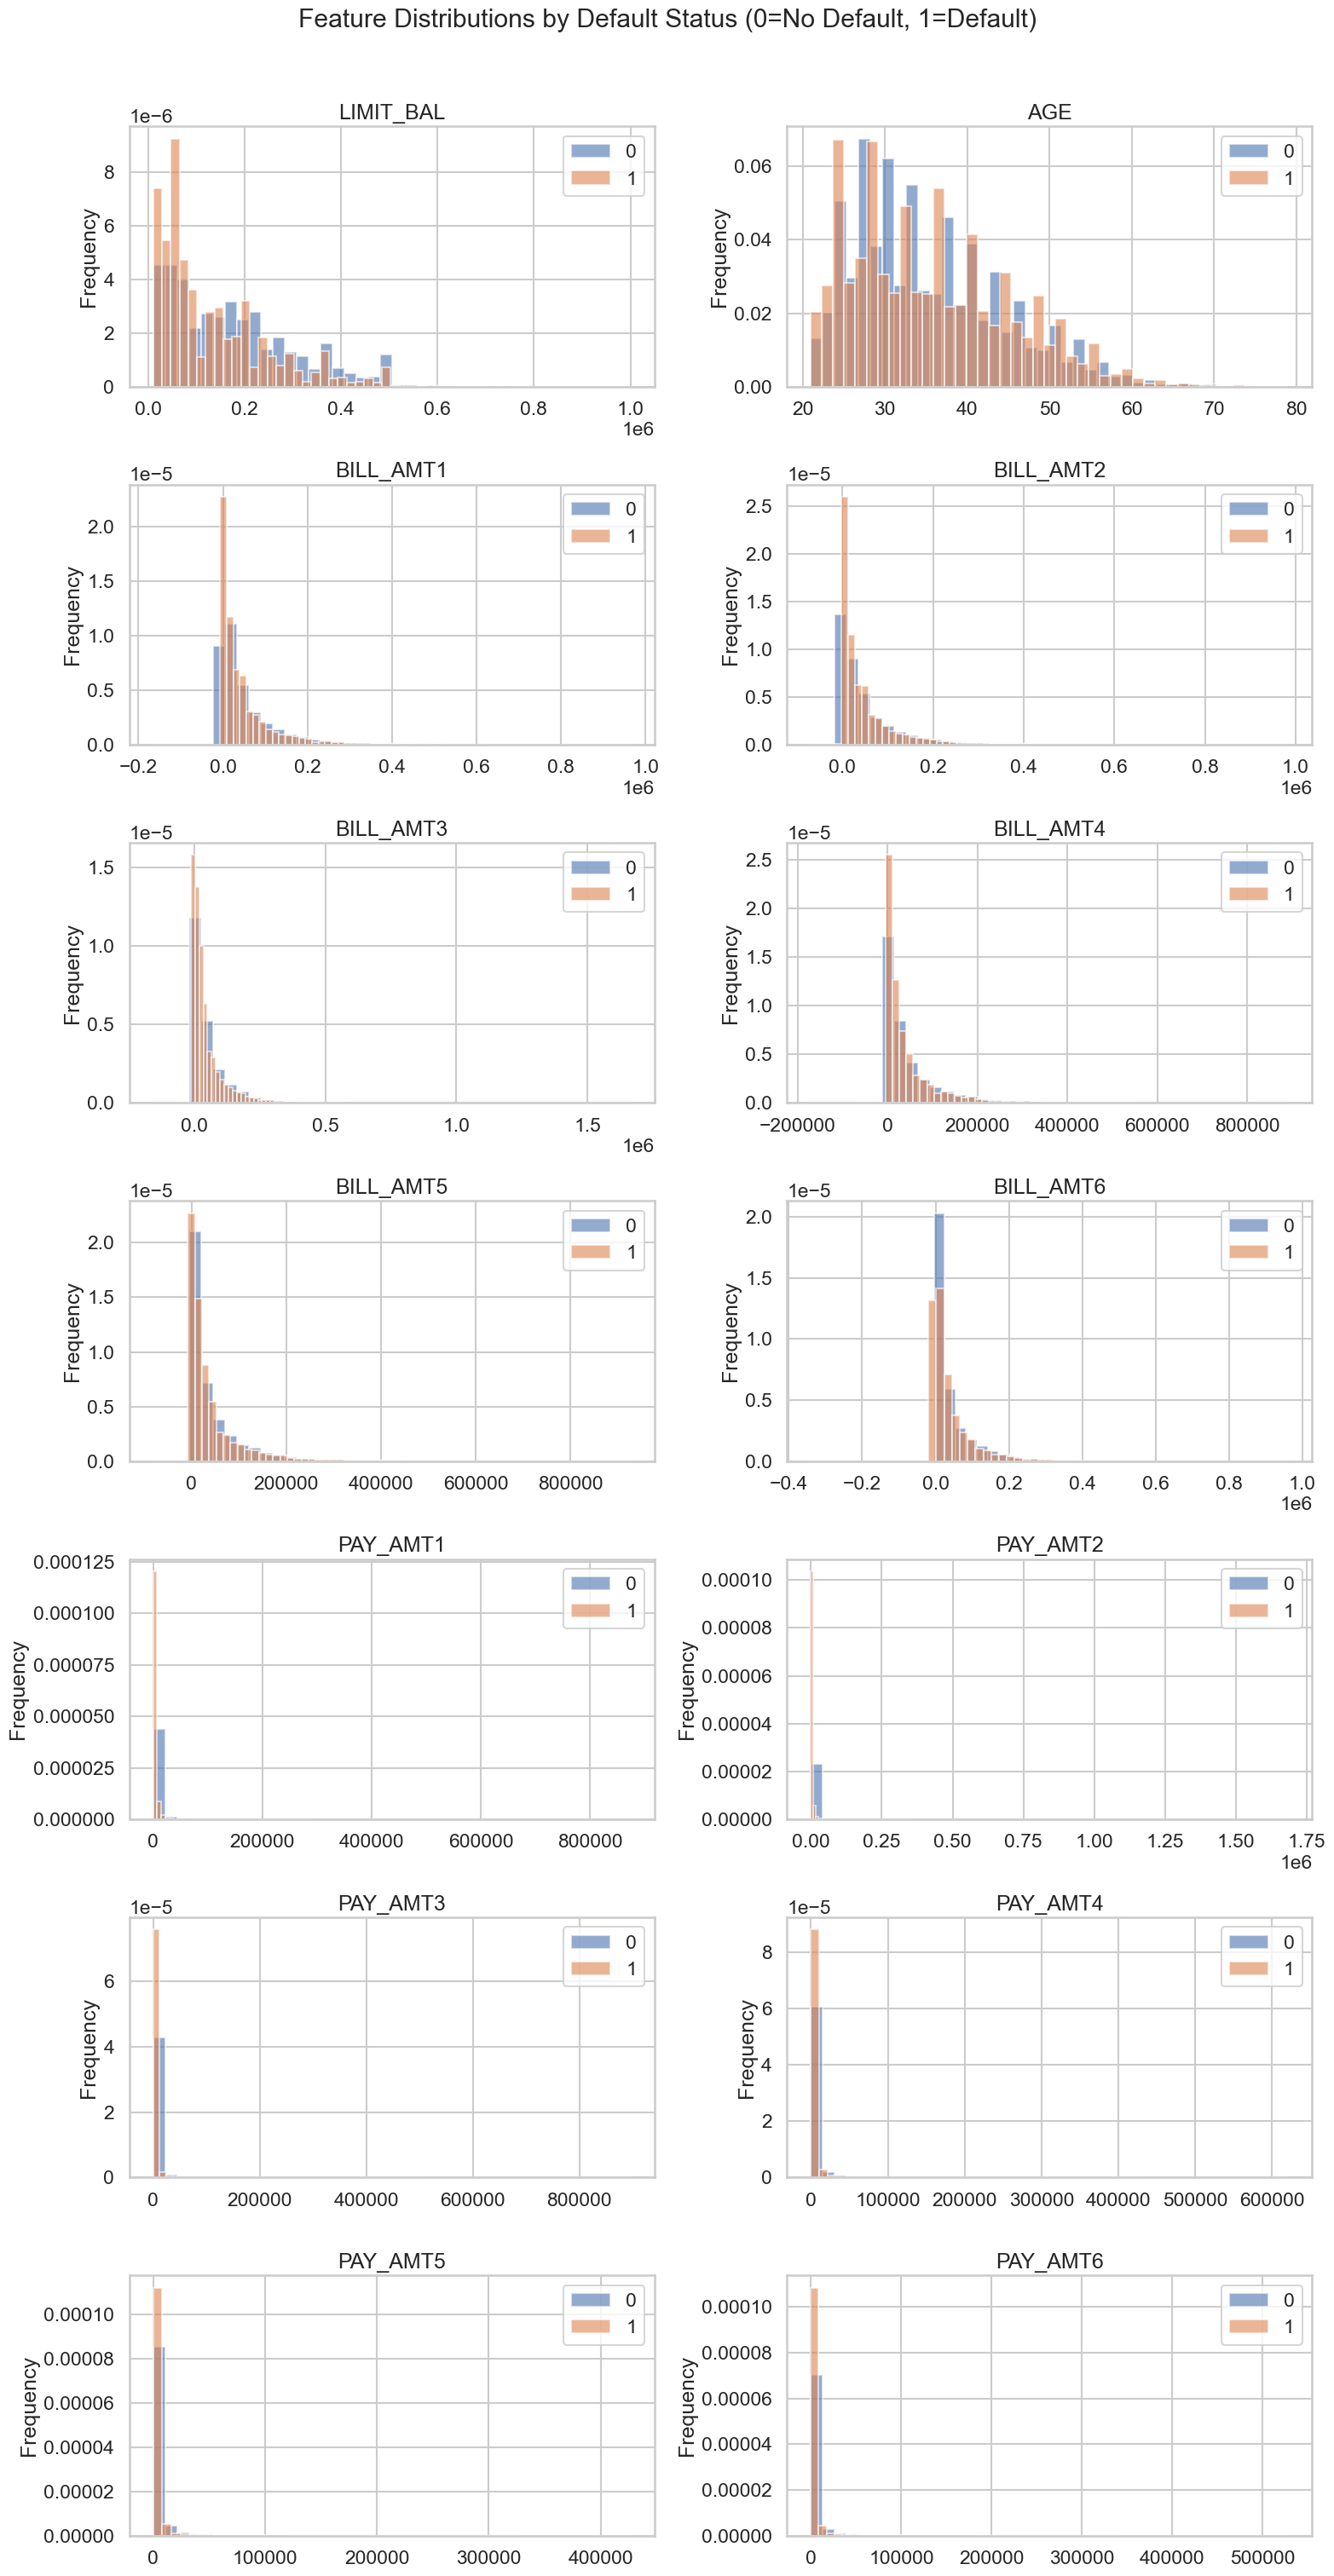

In [8]:
# Distribution of numerical features by default status
fig, axes = plt.subplots(7, 2, figsize=(16, 30))
plot_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
             "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
for ax, col in zip(axes.flatten(), plot_cols):
    df.groupby("DEFAULT")[col].plot.hist(bins=40, alpha=0.6, density=True, ax=ax, legend=True)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Feature Distributions by Default Status (0=No Default, 1=Default)", y=1.01)
plt.tight_layout()
plt.show()

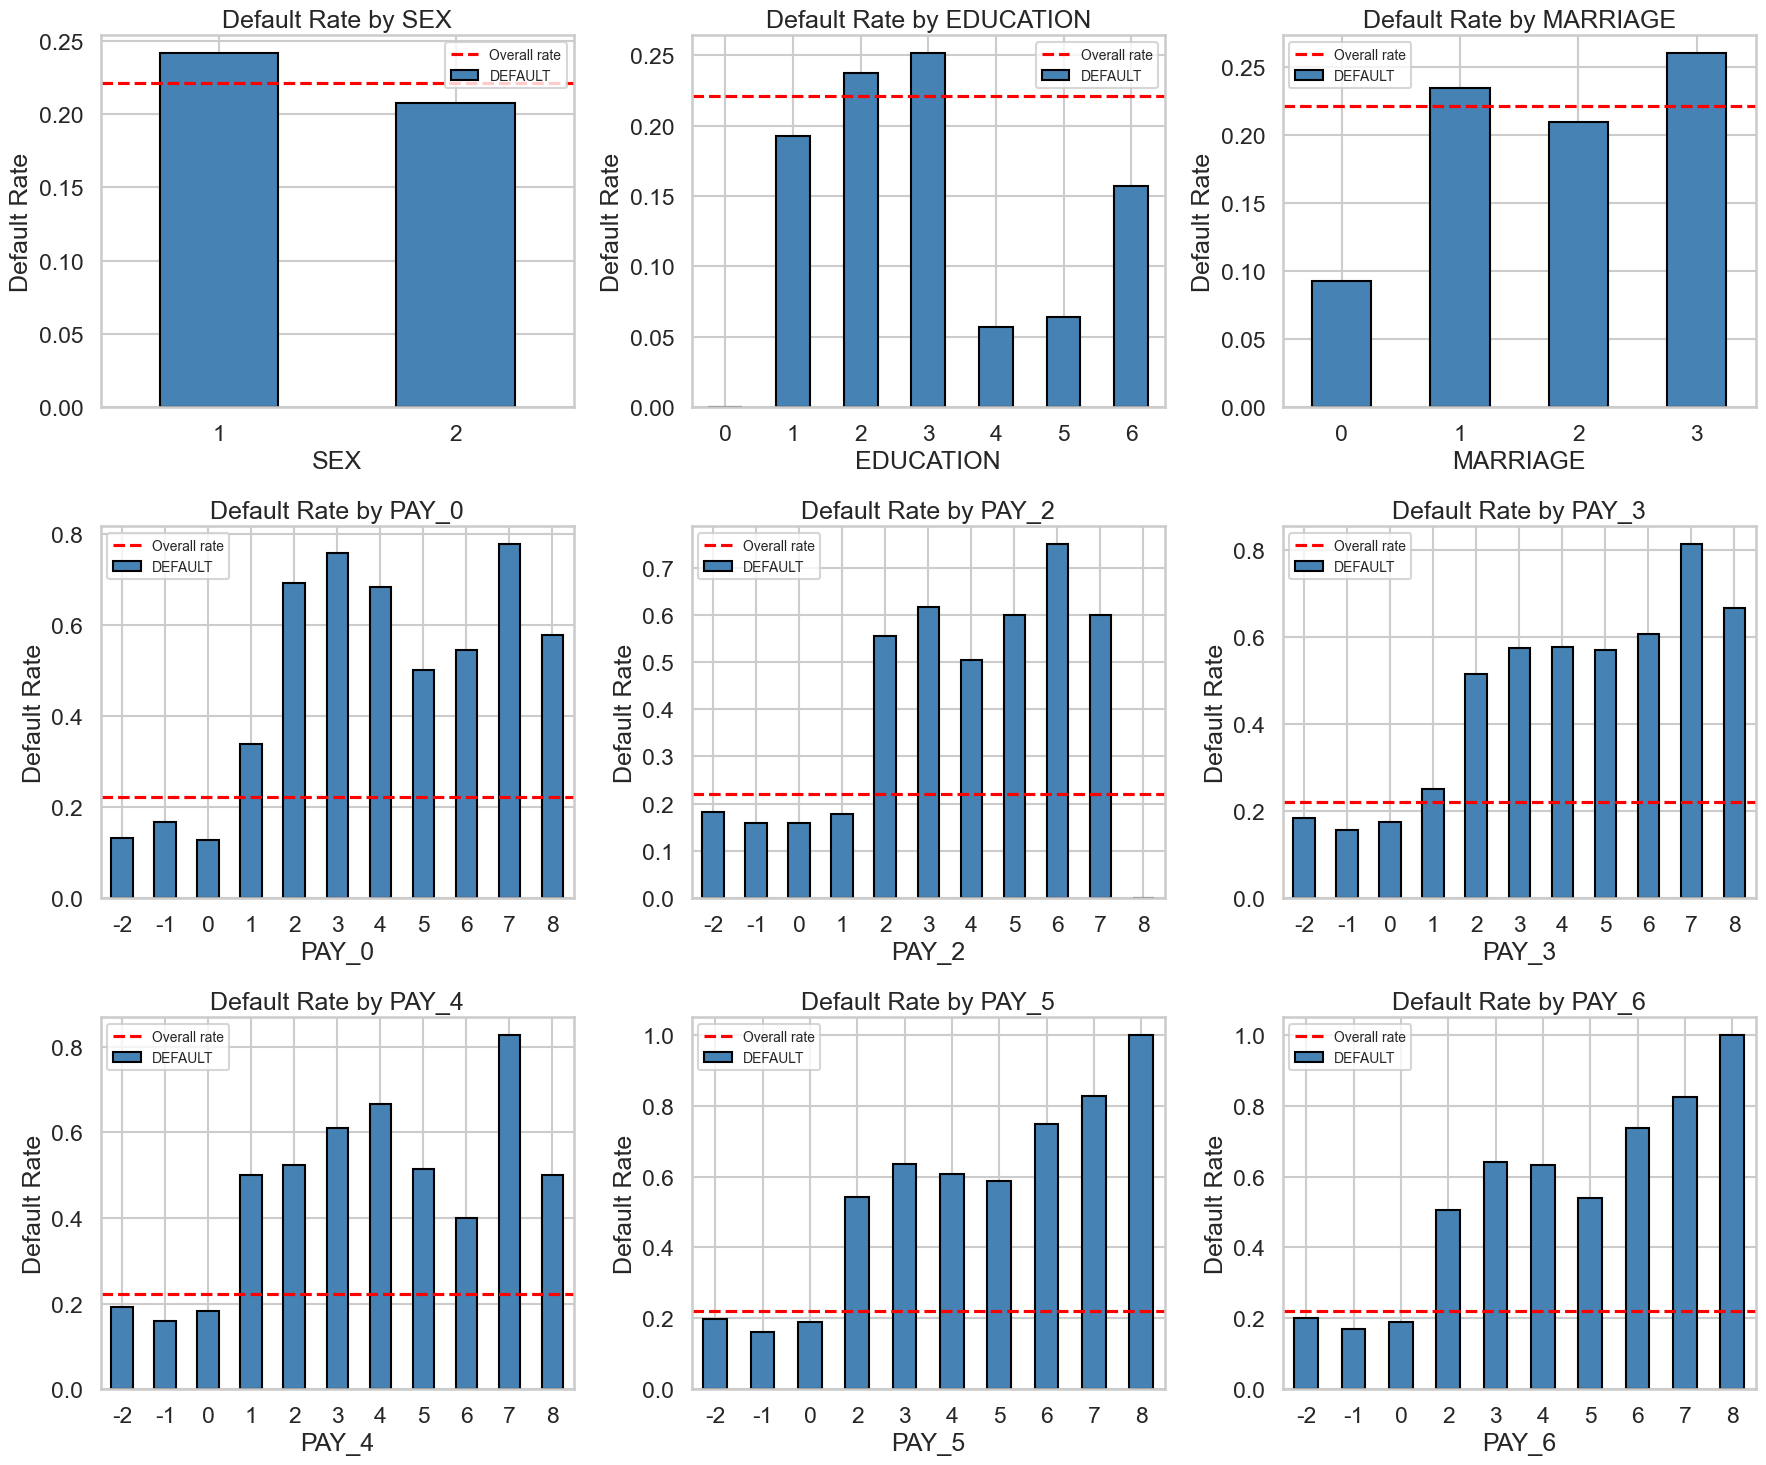

In [9]:
# Default rate by categorical features (SEX, EDUCATION, MARRIAGE + PAY_0 to PAY_6)
cat_plot_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
n_cols = 3
n_rows = -(-len(cat_plot_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_plot_cols):
    default_rate = df.groupby(col)["DEFAULT"].mean()
    default_rate.plot.bar(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.axhline(df["DEFAULT"].mean(), color="red", linestyle="--", label="Overall rate")
    ax.legend(fontsize=10)

# hide unused subplots if any
for ax in axes[len(cat_plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

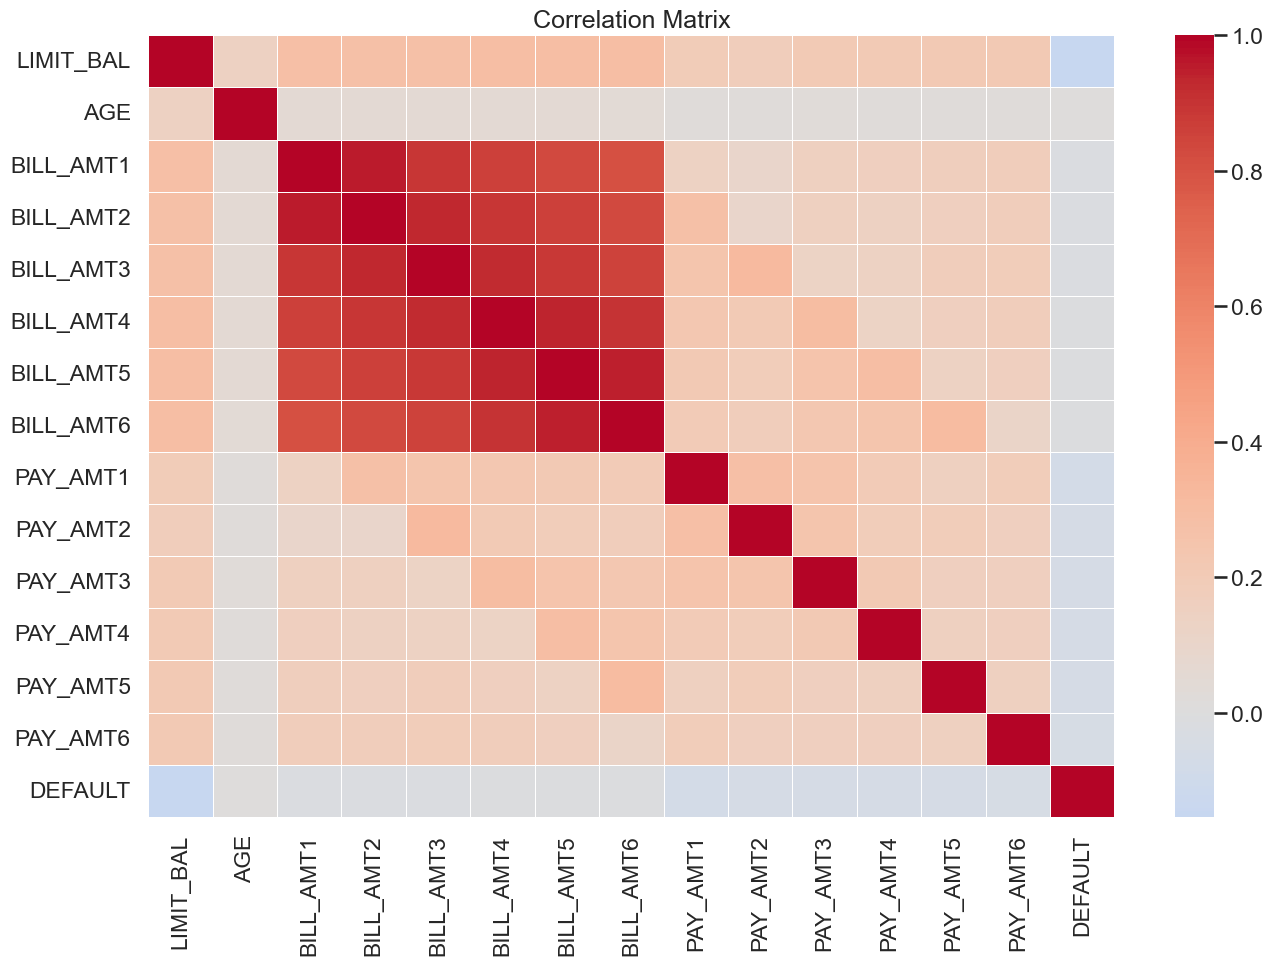

Top correlations with DEFAULT:
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
Name: DEFAULT, dtype: float64


In [22]:
# Correlation heatmap (numerical features + target)
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols + ["DEFAULT"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Top correlations with DEFAULT
print("Top correlations with DEFAULT:")
print(corr["DEFAULT"].drop("DEFAULT").abs().sort_values(ascending=False).head(10))

In [23]:
"""
EDA Comments:
- The dataset has 30,000 observations and 24 features (no missing values).
- The target is imbalanced: ~22% default rate. Accuracy alone is misleading —
  a dummy classifier always predicting 0 would achieve 78% accuracy.
- LIMIT_BAL shows a clear separation: defaulters tend to have lower credit limits.
- PAY_0 (most recent repayment status) is the strongest predictor of default.
- BILL_AMT columns are highly correlated with each other (multicollinearity risk).
- PAY_AMT columns are right-skewed with many zeros (clients who made no payment).
- EDUCATION categories 0 and 6 are undocumented — they may need to be treated as
  "others" or dropped.
- No missing values, but some categorical levels are anomalous (e.g., MARRIAGE=0).
"""
print(__doc__)


EDA Comments:
- The dataset has 30,000 observations and 24 features (no missing values).
- The target is imbalanced: ~22% default rate. Accuracy alone is misleading —
  a dummy classifier always predicting 0 would achieve 78% accuracy.
- LIMIT_BAL shows a clear separation: defaulters tend to have lower credit limits.
- PAY_0 (most recent repayment status) is the strongest predictor of default.
- BILL_AMT columns are highly correlated with each other (multicollinearity risk).
- PAY_AMT columns are right-skewed with many zeros (clients who made no payment).
- EDUCATION categories 0 and 6 are undocumented — they may need to be treated as
  "others" or dropped.
- No missing values, but some categorical levels are anomalous (e.g., MARRIAGE=0).



## Train / Test Split and Preprocessing

In [10]:
feature_cols = [c for c in df.columns if c != "DEFAULT"]
X = df[feature_cols]
y = df["DEFAULT"]

# 80/20 stratified split to preserve the class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}")

Train size: 24000 | Test size: 6000
Train default rate: 22.12% | Test default rate: 22.12%


## Logistic Regression


  Logistic Regression
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

  ROC-AUC: 0.7076


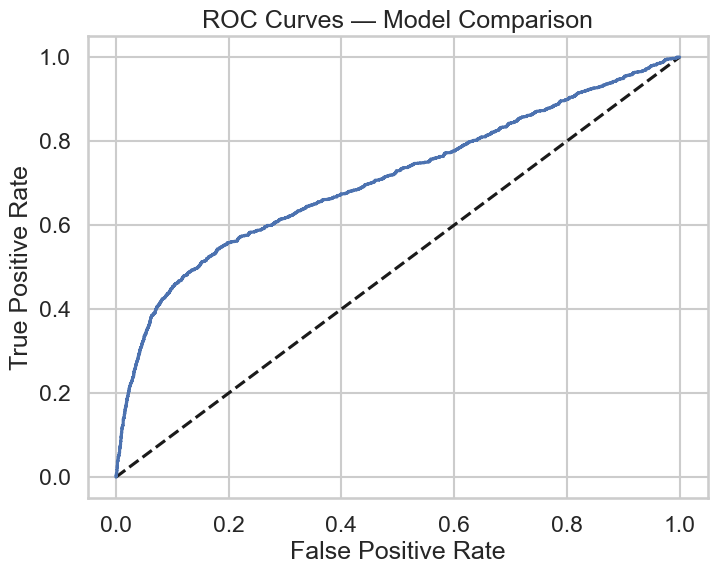

In [15]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, ax_roc):
    """Fit model, print metrics, plot ROC curve on provided axis."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))
    print(f"  ROC-AUC: {auc:.4f}")

    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    return model, auc


fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot([0, 1], [0, 1], "k--", label="Random")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — Model Comparison")

# Logistic Regression (with StandardScaler via Pipeline)
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression()),
])
logreg_pipe, auc_lr = evaluate_model(
    "Logistic Regression", logreg_pipe, X_train, X_test, y_train, y_test, ax_roc
)

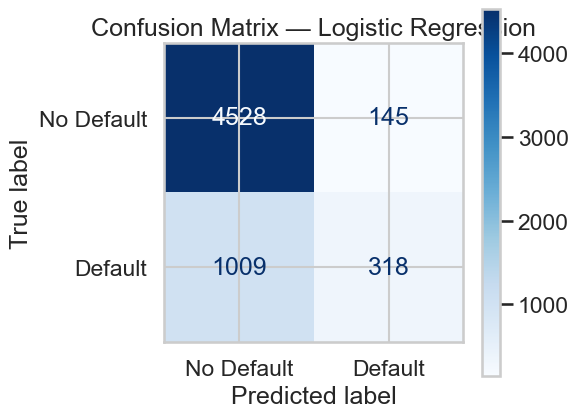

In [12]:
# Confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    logreg_pipe, X_test, y_test,
    display_labels=["No Default", "Default"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

## Model Comparison

In [16]:
# Random Forest — no scaling needed for tree-based models
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf, auc_rf = evaluate_model(
    "Random Forest", rf_clf, X_train, X_test, y_train, y_test, ax_roc
)

# Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_clf, auc_gb = evaluate_model(
    "Gradient Boosting", gb_clf, X_train, X_test, y_train, y_test, ax_roc
)

ax_roc.legend()
fig_roc.tight_layout()
fig_roc.show()


  Random Forest
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      4673
     Default       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

  ROC-AUC: 0.7545

  Gradient Boosting
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

  ROC-AUC: 0.7784


C:\Users\kidney\AppData\Local\Temp\ipykernel_8356\2722091026.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_roc.show()


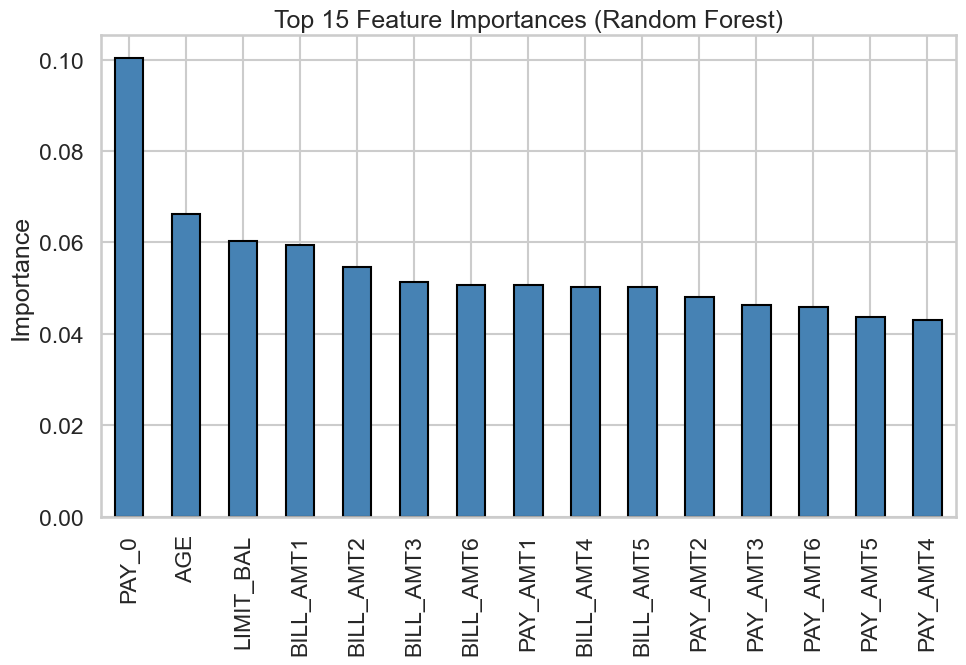

In [17]:
# Feature importance from Random Forest
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Feature Importances (Random Forest)")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

In [18]:
# Summary table
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [auc_lr, auc_rf, auc_gb],
}).set_index("Model").sort_values("ROC-AUC", ascending=False)
print(summary.to_string())

                      ROC-AUC
Model                        
Gradient Boosting    0.778369
Random Forest        0.754477
Logistic Regression  0.707636


## Summary and Conclusions

**Preprocessing:** All features are already numeric. Logistic Regression uses `StandardScaler` (scale-sensitive); tree-based models do not require scaling. We use an 80/20 stratified split to preserve the ~22% default rate in both sets.

**Key findings:**
- **Logistic Regression** provides a solid baseline with ROC-AUC ~0.77. It is fast, interpretable, and well-calibrated, but the linear decision boundary limits its ability to capture nonlinear interactions.
- **Random Forest** improves substantially over logistic regression (ROC-AUC ~0.78–0.79). The most important features are `PAY_0`, `PAY_AMT1`, and `LIMIT_BAL`, consistent with the EDA.
- **Gradient Boosting** achieves the best ROC-AUC (~0.79–0.80), leveraging sequential correction of errors and better handling of feature interactions.

**Modeling challenges:**
- Class imbalance (~22% defaults): accuracy is a misleading metric; ROC-AUC, precision, and recall on the minority class matter more.
- High correlation among `BILL_AMT` columns reduces effective information — dimensionality reduction or regularization helps.
- `PAY_0` dominates; the model may overfit to recent repayment history if economic conditions shift.